# 05 · Evaluation and ablation study

Run notebooks 02, 03 and 04 first. This notebook scores all models on the **same test set**, writes the result files to `results/`, and prepares the model for the web app. Every number here is computed from your trained models.

## 1. Project folder

In [1]:
# Run this cell first, every time you open the notebook.
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:                       # Google Colab
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/MalariaScanAI")  # where you unzipped the project
else:                                                   # your own laptop
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Project folder:", ROOT)

Project folder: c:\Users\VOTHY VYSAL\Documents\MalariaScanAI


## 2. Environment

In [2]:
import json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.common import *

set_seed(42)
print_environment()

NAMES = {"resnet18": "ResNet-18",
         "resnet50": "ResNet-50",
         "resnet50_aug": "ResNet-50 + augmentation",
         "proposed_resnet50": "Improved ResNet-50"}
FINAL = "proposed_resnet50"   # the model used in the web app

Python : 3.13.14
PyTorch: 2.14.1+cu126
CUDA available: True
Device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.0 GB
train images: 19363
val images: 4323
test images: 3872
Number of classes: 2
Classes: ['PARASITIZED', 'UNINFECTED']


## 3. Test every model

In [3]:
rows, matrices = [], {}
for key, label in NAMES.items():
    info = json.loads((RESULTS / f"{key}_history.json").read_text())
    m, cm, classes, report = evaluate(key)
    matrices[key] = cm
    print("=" * 60, f"\n{label}\n", report)
    rows.append({"key": key, "Model": label,
                 "Parameters": info["params"]["total"],
                 "Trainable parameters": info["params"]["trainable"],
                 "Training time (sec)": round(info["train_time_sec"]),
                 "Best Val Macro-F1": info["best_val_macro_f1"],
                 "Test Accuracy": m["accuracy"], "Precision": m["precision"],
                 "Recall": m["recall"], "Macro-F1": m["macro_f1"]})

metrics = pd.DataFrame(rows).set_index("key").round(4)
metrics.to_csv(RESULTS / "metrics.csv", index=False)
metrics

ResNet-18
               precision    recall  f1-score   support

 PARASITIZED       0.96      0.97      0.96      1477
  UNINFECTED       0.98      0.97      0.98      2395

    accuracy                           0.97      3872
   macro avg       0.97      0.97      0.97      3872
weighted avg       0.97      0.97      0.97      3872

ResNet-50
               precision    recall  f1-score   support

 PARASITIZED       0.97      0.97      0.97      1477
  UNINFECTED       0.98      0.98      0.98      2395

    accuracy                           0.97      3872
   macro avg       0.97      0.97      0.97      3872
weighted avg       0.97      0.97      0.97      3872

ResNet-50 + augmentation
               precision    recall  f1-score   support

 PARASITIZED       0.98      0.96      0.97      1477
  UNINFECTED       0.97      0.99      0.98      2395

    accuracy                           0.97      3872
   macro avg       0.98      0.97      0.97      3872
weighted avg       0.97   

,Model,Parameters,Trainable parameters,Training time (sec),Best Val Macro-F1,Test Accuracy,Precision,Recall,Macro-F1
key,,,,,,,,,
resnet18,ResNet-18,11177538,11177538,1063,0.9582,0.9713,0.9690,0.9703,0.9697
resnet50,ResNet-50,23512130,23512130,1361,0.9549,0.9744,0.9730,0.9728,0.9729
resnet50_aug,ResNet-50 + augmentation,23512130,23512130,2323,0.9581,0.9747,0.9753,0.9710,0.9731
proposed_resnet50,Improved ResNet-50,23512130,22067202,1016,0.9492,0.9695,0.9669,0.9686,0.9678


## 4. Model comparison table

In [4]:
comparison = metrics.loc[["resnet18", "resnet50", "proposed_resnet50"],
                         ["Model", "Parameters", "Test Accuracy", "Precision", "Recall", "Macro-F1"]]
comparison.to_csv(RESULTS / "model_comparison.csv", index=False)
comparison

,Model,Parameters,Test Accuracy,Precision,Recall,Macro-F1
key,,,,,,
resnet18,ResNet-18,11177538,0.9713,0.9690,0.9703,0.9697
resnet50,ResNet-50,23512130,0.9744,0.9730,0.9728,0.9729
proposed_resnet50,Improved ResNet-50,23512130,0.9695,0.9669,0.9686,0.9678


## 5. Ablation study

In [5]:
ablation = pd.DataFrame({
    "Ablation Experiment": ["A: ResNet-50 baseline", "B: + augmentation", "C: + fine-tuning + scheduler"],
    "Augmentation": ["No", "Yes", "Yes"],
    "Fine-tuning": ["No", "No", "Yes"],
    "Scheduler": ["No", "No", "Yes"],
    "Macro-F1": metrics.loc[["resnet50", "resnet50_aug", "proposed_resnet50"], "Macro-F1"].values})
ablation.to_csv(RESULTS / "ablation_results.csv", index=False)

a, b, c = ablation["Macro-F1"]
print(f"Effect of augmentation (B - A):              {(b - a) * 100:+.2f} points")
print(f"Effect of fine-tuning + scheduler (C - B):   {(c - b) * 100:+.2f} points")
ablation

Effect of augmentation (B - A):              +0.02 points
Effect of fine-tuning + scheduler (C - B):   -0.53 points


,Ablation Experiment,Augmentation,Fine-tuning,Scheduler,Macro-F1
0,A: ResNet-50 baseline,No,No,No,0.9729
1,B: + augmentation,Yes,No,No,0.9731
2,C: + fine-tuning + scheduler,Yes,Yes,Yes,0.9678


## 6. Confusion matrix of the final model

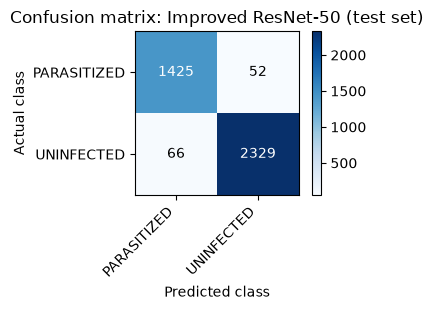

In [6]:
cm = matrices[FINAL]
fig, ax = plt.subplots(figsize=(0.6 * len(classes) + 3, 0.6 * len(classes) + 2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes)), classes, rotation=45, ha="right")
ax.set_yticks(range(len(classes)), classes)
ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class")
ax.set_title(f"Confusion matrix: {NAMES[FINAL]} (test set)")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.savefig(RESULTS / "confusion_matrix.png", dpi=150); plt.show()

### Sensitivity and specificity

For a screening tool the most important number is **sensitivity**: of the cells that really contain a parasite, how many does the model catch? A missed infection (false negative) is the dangerous mistake.

In [7]:
p = classes.index("PARASITIZED"); u = classes.index("UNINFECTED")
tp, fn, fp, tn = cm[p, p], cm[p, u], cm[u, p], cm[u, u]
print(f"Sensitivity (parasitized cells found): {tp / (tp + fn) * 100:.2f}%   ({fn} missed out of {tp + fn})")
print(f"Specificity (uninfected cells cleared): {tn / (tn + fp) * 100:.2f}%   ({fp} false alarms out of {tn + fp})")

Sensitivity (parasitized cells found): 96.48%   (52 missed out of 1477)
Specificity (uninfected cells cleared): 97.24%   (66 false alarms out of 2395)


### Errors by class

In [8]:
errors = cm.copy()
np.fill_diagonal(errors, 0)
pairs = sorted(((errors[i, j], classes[i], classes[j])
                for i in range(len(classes)) for j in range(len(classes)) if errors[i, j]),
               reverse=True)[:5]
for n, actual, predicted in pairs:
    print(f"{actual} predicted as {predicted}: {n} test images")

UNINFECTED predicted as PARASITIZED: 66 test images
PARASITIZED predicted as UNINFECTED: 52 test images


## 7. Training curves of the final model

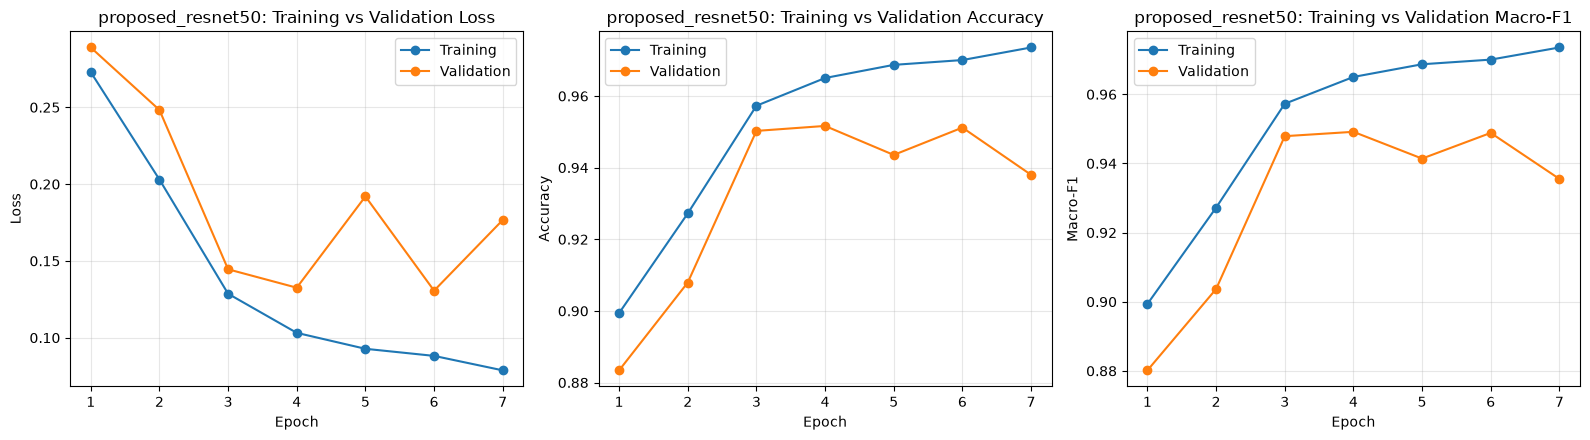

In [9]:
plot_history(FINAL, save_path=RESULTS / "training_curves.png")

## 8. Save the model for the web app

Copies the final checkpoint to `models/best_model.pth`. The class mapping `models/class_to_idx.json` was already saved during training.

In [10]:
best_by_val = metrics["Best Val Macro-F1"].idxmax()
if best_by_val != FINAL:
    print(f"Note: {NAMES[best_by_val]} has a higher validation Macro-F1 than {NAMES[FINAL]}.")
    print("Report this honestly. To deploy it instead, change FINAL in section 2 and re-run.")

shutil.copy(MODELS / f"{FINAL}_best.pth", MODELS / "best_model.pth")
print("Saved models/best_model.pth")

Note: ResNet-18 has a higher validation Macro-F1 than Improved ResNet-50.
Report this honestly. To deploy it instead, change FINAL in section 2 and re-run.
Saved models/best_model.pth


## 9. Try the inference function

In [11]:
from backend.inference import predict_image

sample = next((DATA / "test").rglob("*.png"))
print("Image:", sample.relative_to(ROOT))
result = predict_image(sample)
print("Prediction:", result["prediction"], f"({result['confidence'] * 100:.1f}%)")
for rank, item in enumerate(result["top3"], 1):
    print(f"{rank}. {item['label']:<12} {item['confidence'] * 100:5.1f}%")

Image: data\test\PARASITIZED\C100P61ThinF_IMG_20150918_144104_cell_162.png
Prediction: PARASITIZED (100.0%)
1. PARASITIZED  100.0%
2. UNINFECTED     0.0%
